# Parte teórica

Classifique as afirmações em Verdadeiro ou Falso, justifique as afirmativas falsas

1 - O espaço de cores RGB é amplamente utilizado pois é o mais intuitivo para seres humanos

In [2]:
# F - O espaço mais intuitivo é o HSV

2 - Imagens vetoriais apresentam serrilhamento quando são ampliadas

In [3]:
# F - Imagens matriciais que apresentam serrilhamento

3 - A lógica XOR aplicada em uma imagem detecta os pixels que mudaram de valor

In [4]:
# V

4 - O código abaixo representa um circulo com 110px de altura, 128px de largura e rotacionado em 64 graus.

```<circle cx='110' cy='128' r='64' fill='red'/>```

In [5]:
# F - cx e cy representam as coordenadas do centro e r o raio

5 - Algumas imagens podem ter um quarto canal chamado Alpha que representa a opacidade do pixel

In [6]:
# V

# Parte prática

## Material de apoio

### Importações

```
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
```

### Manipulação de imagens

```
img = Image.open('nome.extensão')
img = np.array(Image.open('nome.extensão'))
img = img[:, :, :3]
img_pil = Image.fromarray(img_np)
img.save('nome.png')
Image.fromarray(img).save('nome_arquivo.extensao')
(l,c,p) = img.shape
```

### Greyscale

#### Algoritmo genérico, substituir o método escolhido
```
img_avg = np.zeros(shape=(l, c), dtype=np.uint8)
for i in range(l):
    for j in range(c):
        r = float(img_np[i, j, 0])
        g = float(img_np[i, j, 1])
        b = float(img_np[i, j, 2])
        
        img_avg[i, j] = (aplicar método)
```

#### Métodos: 

Lightness: $\frac{max(R,G,B)+min(R,G,B)}{2}$

Average: $\frac{R+G+B}{3}$

Luminosity: $0.2126 \cdot R + 0.7152 \cdot G + 0.0722 \cdot B$

### Escalonamento com nearest neighbor

```
ls, cs = l * sy, c * sx
mario_nn = np.zeros(shape=(ls, cs, p), dtype=np.uint8)

for i in range(ls):
    for j in range(cs):
        new_y = int(np.floor(i * (l / ls)))
        new_x = int(np.floor(j * (c / cs)))
        
        mario_nn[i, j] = mario[new_y, new_x]
```

### Cisalhamento

```
img_shear = np.zeros((int(l * (1.1 + cy)), int(c * (1.1 + cx)), p), dtype=np.uint8)
for i in range(l):
    for j in range(c):
        new_x = int(j + cx * i)
        new_y = int(cy * j + i)
        
        img_shear[new_y, new_x] = img[i, j]
```

### Imagem grayscale para imagem binária de 3 canais

``` 
bin = np.zeros(shape=(l,c,3),dtype=np.uint8)
    
for i in range(l):
    for j in range(c):
        if img[i,j] > thresh: 
            bin[i,j,:] = 255 
        else: 
            bin[i,j,:] = 0

```

**1 -** Importe as bibliotecas que serão usadas

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

**2 -** Abra as imagens horse.jpg e landscape.png, retire o canal alpha se necessário, exiba essas imagens e mostre o formato de cada uma

Dimesões da imagem horse: (768, 1024, 3)
Dimesões da imagem landscape: (384, 512, 3)


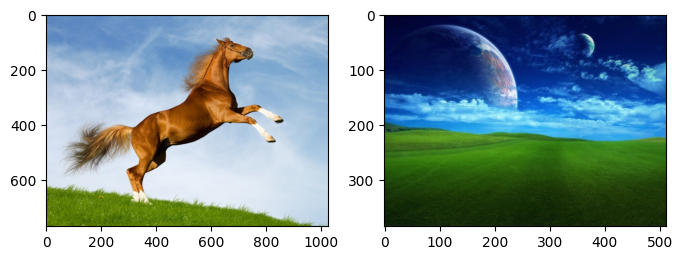

In [8]:
horse = np.array(Image.open("horse.jpg"))[:, :, :3]

landscape = np.array(Image.open("landscape.jpg"))[:, :, :3]

plt.figure(figsize=(8,8))

plt.subplot(2,2,1)
plt.imshow(horse)
print(f"Dimesões da imagem horse: {horse.shape}")

plt.subplot(2,2,2)
plt.imshow(landscape)
print(f"Dimesões da imagem landscape: {landscape.shape}")

**3 -** Crie uma função que realize o escalonamento de uma imagem que receba como parâmetro uma **imagem, sx e sy**, sendo sx e sy os fatores de escalonamento e **retorne a imagem escalonada**, em seguida aplique o escalonamento na imagem "landscape" para que fique do mesmo tamanho da imagem "horse". Exiba o resultado.

Dimesões da imagem landscape: (384, 512, 3)
Dimesões da imagem landscape escalonada: (768, 1024, 3)


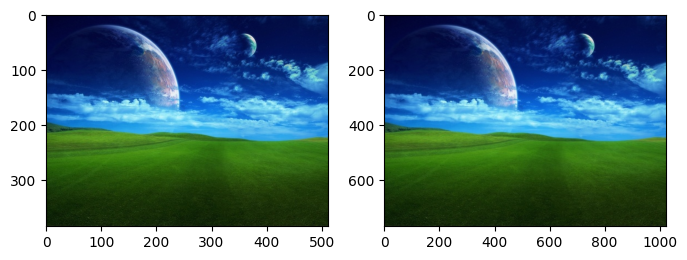

In [9]:
def escalonamento(img,sx,sy):
    l,c,p = img.shape
    ls, cs = l * sy, c * sx
    img_nn = np.zeros(shape=(ls, cs, p), dtype=np.uint8)

    for i in range(ls):
        for j in range(cs):
            new_y = int(np.floor(i * (l / ls)))
            new_x = int(np.floor(j * (c / cs)))
            
            img_nn[i, j] = img[new_y, new_x]

    return img_nn

landscape_esc = escalonamento(landscape,2,2)

plt.figure(figsize=(8,8))

plt.subplot(2,2,1)
plt.imshow(landscape)
print(f"Dimesões da imagem landscape: {landscape.shape}")

plt.subplot(2,2,2)
plt.imshow(landscape_esc)
print(f"Dimesões da imagem landscape escalonada: {landscape_esc.shape}")


**4 -** Crie uma função para aplicar um método grayscale de sua escolha, que receba como **parâmetro uma imagem e retorne uma imagem em greyscale**. Aplique essa função na **imagem "horse"** e mostre o resultado.

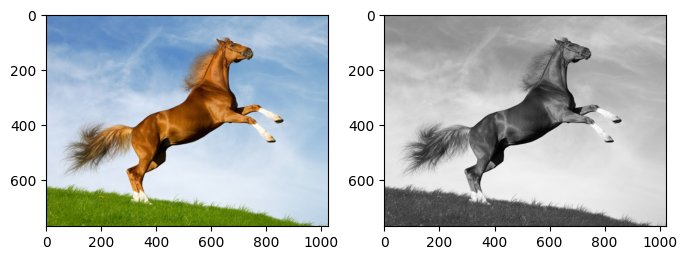

In [16]:
def grayscale(img):
    (l,c,p) = img.shape

    img_avg = np.zeros(shape=(l, c), dtype=np.uint8)
    for i in range(l):
        for j in range(c):
            r = float(img[i, j, 0])
            g = float(img[i, j, 1])
            b = float(img[i, j, 2])
            
            img_avg[i, j] = (r + g + b)/3

    return img_avg

horse_gray = grayscale(horse)

plt.figure(figsize=(8,8))

plt.subplot(2,2,1)
plt.imshow(horse)

plt.subplot(2,2,2)
plt.imshow(horse_gray, cmap = 'gray')

**5 -** Crie uma função para transformar uma imagem grayscale em uma imagem binária, que receba como **parâmetro uma imagem e o threshhold** para realizar a operação e retorne uma imagem binária. Aplique essa função na imagem resultante da **etapa anterior com threshold de valor 135** e mostre o resultado.

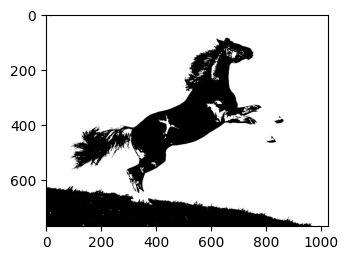

In [11]:
def grayscale_bin(img,thresh):
    (l,c) = img.shape
    bin = np.zeros(shape=(l,c,3),dtype=np.uint8)
    
    for i in range(l):
        for j in range(c):
            if img[i,j] > thresh: 
                bin[i,j,:] = 255 
            else: 
                bin[i,j,:] = 0

    return bin

horse_bin = grayscale_bin(horse_gray,135)

plt.figure(figsize=(8,8))

plt.subplot(2,2,1)
plt.imshow(horse_bin)

**6 -** Realize a operação NOT com a imagem da **etapa anterior** e mostre o resultado

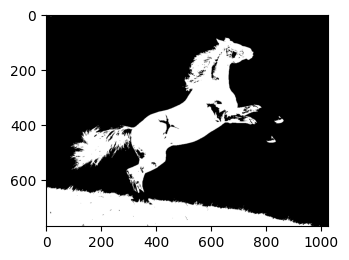

In [12]:
horse_bin_not = ~horse_bin

plt.figure(figsize=(8,8))

plt.subplot(2,2,1)
plt.imshow(horse_bin_not)

**7 -** Aplique a imagem da **questão anterior como uma máscara (Lógica E) com a imagem resultante do escalonamento na questão 3**. Mostre o resultado

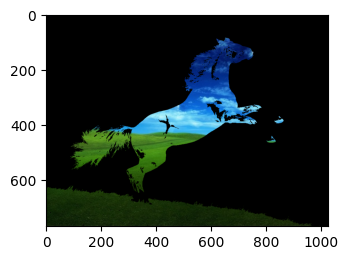

In [13]:
horse_and = horse_bin_not & landscape_esc

plt.figure(figsize=(8,8))

plt.subplot(2,2,1)
plt.imshow(horse_and)

**8 -** Crie uma função para aplicar o cisalhamento em cima de uma imagem, que **recebe como parâmetro uma imagem, cx e cy**, sendo cx e cy os coeficientes do cisalhamento e retorne a imagem com o efeito aplicado. 
**Aplique a função na imagem anterior com cx=0.3 e cy=0.2**. Mostre o resultado.

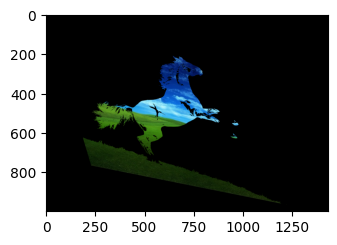

In [14]:
def cisalhamento(img,cx,cy):
    (l,c,p) = img.shape
    img_shear = np.zeros((int(l * (1.1 + cy)), int(c * (1.1 + cx)), p), dtype=np.uint8)
    for i in range(l):
        for j in range(c):
            new_x = int(j + cx * i)
            new_y = int(cy * j + i)
            
            img_shear[new_y, new_x] = img[i, j]

    return img_shear

horse_and_cis = cisalhamento(horse_and,0.3,0.2)

plt.figure(figsize=(8,8))

plt.subplot(2,2,1)
plt.imshow(horse_and_cis)

**9 -** Salve a imagem da questão anterior no disco com o nome "resultado.jpg"

In [15]:
Image.fromarray(horse_and_cis).save('resultado.jpg')